# Figure 2: Dual occluder task

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-07-01 17:15:26,649::INFO::settings.py::Setting loglevel to INFO
2025-07-01 17:15:26,650::INFO::settings.py::Setting stores to {}
2025-07-01 17:15:26,651::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-01 17:15:26,653::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-01 17:15:26,654::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-01 17:15:26,656::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-07-01 17:15:26,657::INFO::settings.py::Setting database.user to celia
2025-07-01 17:15:26,658::INFO::settings.py::Setting database.password to celia_mathislab
2025-07-01 17:15:26,831::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-07-01 17:15:26,937::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:27,393::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:27,393::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:27,876::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:27,876::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,027::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,027::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,353::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,353::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,676::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,676::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities,YBinnedXYTrajectory
from vr4mice.schema.session_metrics import TrialMetrics, SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM

import statsmodels.api as sm
from statsmodels.formula.api import ols
from vr4mice.analysis.stats import plot_aperture_heatmap, get_multi_performance_p_val

from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/Figure2/"

2025-07-01 17:15:28,904::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:28,904::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:29,051::INFO::table.py::could not log event in table ~log
2025-07-01 17:15:29,051::INFO::table.py::could not log event in table ~log


## Example trajectories (Pheasant_2024-08-15_2)

In [5]:
# Load dataset and box positions
df = DataFrame().get_data(
    key={"dataset": "Pheasant_2024-08-15_2"},
    columns=[
        "dataset",
        "reward",
        "x",
        "y",
        "trial",
        "aperture",
        "iti",
        "trial_left_choice",
        "trial_duration",
        "trial_tortuosity",
    ],
)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

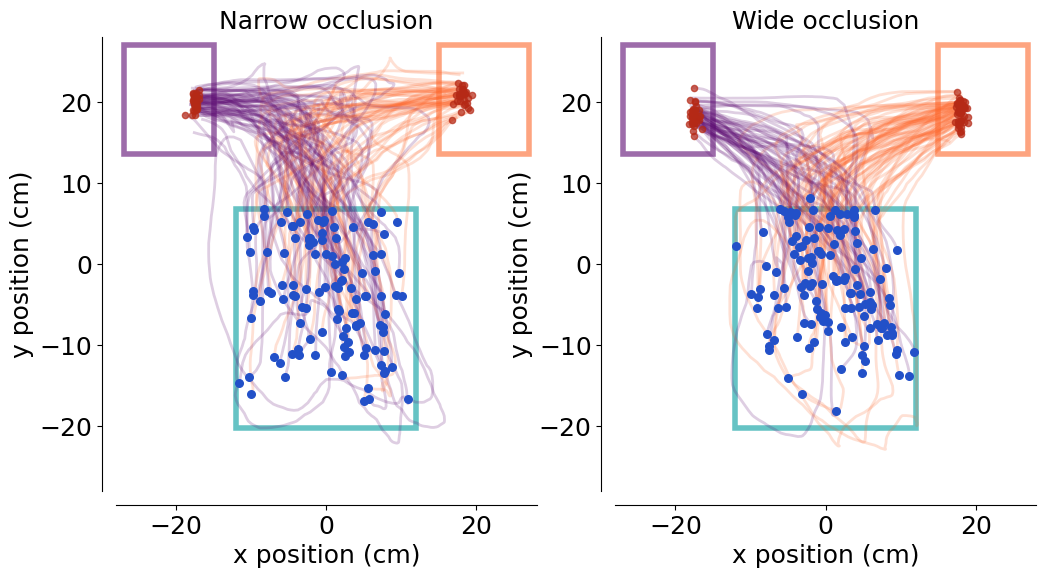

In [6]:
df = df[df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(df)

ax = plotting.plot_session(
    df=j_shaped,
    box_df=box_df,
    per_aperture=True,
    per_side=True,
)

ax[0].set_title("Narrow occlusion")
ax[1].set_title("Wide occlusion")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_example_session_trajectory_plot_dual_occluder.svg", transparent=True)

## Combined sessions analysis
Fetching the data:

In [7]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)


In [8]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.dual_occluder_inclusion_criteria(trial_df, return_excluded=False)

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

Excluded datasets:  ['J731_2024-12-06_1' 'J731_2024-12-04_1' 'J729_2024-11-29_1'
 '31728_2025-03-06_1' '31728_2025-03-05_1']


In [9]:
mouse_list

array(['Pheasant_2024-08-21_1', 'Pheasant_2024-08-20_1',
       'Pheasant_2024-08-19_1', 'Pheasant_2024-08-16_1',
       'Pheasant_2024-08-15_2', 'Oribi_2024-08-22_1',
       'Oribi_2024-08-21_1', 'Oribi_2024-08-20_1', 'Oribi_2024-08-19_1',
       'Oribi_2024-08-16_1', 'Nightingale_2024-08-14_1',
       'Nightingale_2024-08-13_1', 'Nightingale_2024-08-12_1',
       'Nightingale_2024-08-11_1', 'Nightingale_2024-08-10_1',
       'Lemming_2024-08-13_1', 'Lemming_2024-08-12_1',
       'Lemming_2024-08-11_1', 'Lemming_2024-08-10_1',
       'Kiwi_2024-08-14_1', 'Kiwi_2024-08-13_1', 'Kiwi_2024-08-12_2',
       'Kiwi_2024-08-11_4', 'Kiwi_2024-08-10_2', 'Jacana_2024-08-19_1',
       'Jacana_2024-08-16_1', 'Jacana_2024-08-15_1',
       'Jacana_2024-08-14_1', 'Jacana_2024-08-13_1', 'J731_2024-12-09_1',
       'J731_2024-12-05_1', 'J729_2024-12-10_1', 'J729_2024-12-04_1',
       'J729_2024-12-03_1', 'J729_2024-12-02_1', 'J729_2024-12-01_1',
       'J729_2024-11-30_1', '31728_2025-03-21_1', '31728_

In [10]:
trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2025-07-01 17:15:43,159::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,159::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,172::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,172::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,256::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=5.81236275608486, pvalue=6.850432270264985e-07, df=43)
              mean       sem
aperture                    
12.0      0.862708  0.010135
4.3       0.758126  0.014278


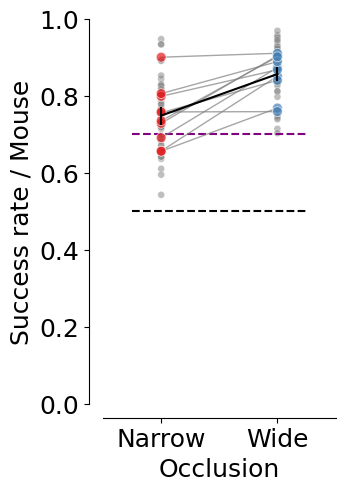

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Mouse")
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "Figure2_trial_reward.svg", transparent=True)

2025-07-01 17:15:43,548::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,548::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,556::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,556::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:43,590::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=7.176569859891019, pvalue=7.148814431559152e-09, df=43)
              mean       sem
aperture                    
12.0      0.862708  0.010135
4.3       0.758126  0.014278


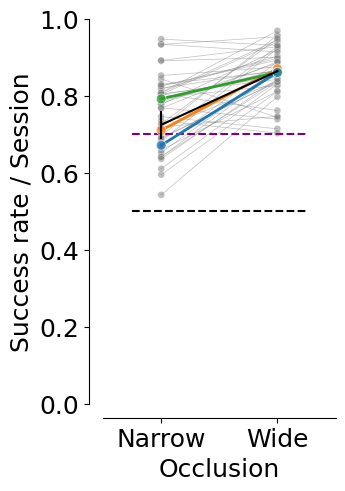

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_lab=True,
)
ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])

sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "Figure2_trial_reward_per_lab.svg", transparent=True)


2025-07-01 17:15:44,071::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,071::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,078::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,078::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,101::INFO::category.py::Using categorical un

wide occlusion mean:  0.5036019322606283 std:  0.03954979212420795
narrow occlusion mean:  0.49639806773937173 std:  0.03954979212420796


TtestResult(statistic=0.597207926999779, pvalue=0.553500499897813, df=43)

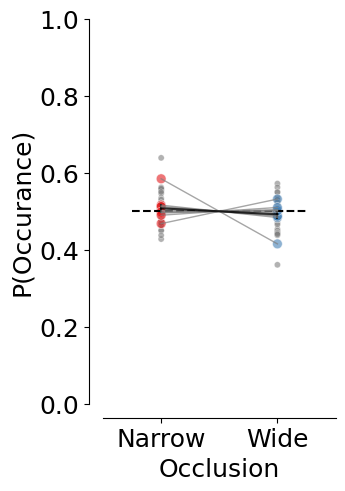

In [13]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Occlusion")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure2_dual_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide occlusion mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow occlusion mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

2025-07-01 17:15:44,356::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,356::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,363::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,363::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 17:15:44,437::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-2.2661073143039685, pvalue=0.028534550357442654, df=43)
              mean       sem
aperture                    
12.0      0.522741  0.017495
4.3       0.579952  0.020673


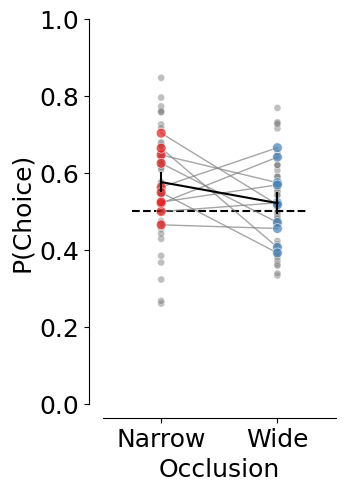

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
ax.set_ylim(0, 1)
plt.legend([], [], frameon=False)
plt.ylabel("P(Choice)")
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_dual_occluder_choice_proba.svg", transparent=True)

## Trajectory analysis

In [15]:
xy_df = []
for m in mouse_list:
    #print(m)
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df ["mouse_name"] = xy_df.dataset.str.split("_").str [0]


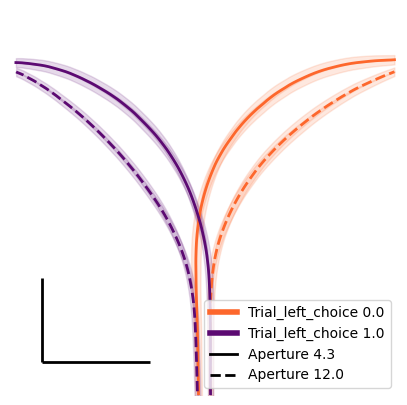

In [16]:
# mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df, index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
# mean and error by whole group
mean_group = analysis.mean_xy_trajectory(mean_mouse, index_columns= ["aperture",  "trial_left_choice", "trial_length"])
# plot_mean_trajectories
plotting.plot_mean_xy_trajectory(mean_group,cmap = plotting.colors_choice [::-1],color_by="choice", style_by="aperture")
plt.savefig("figure_2_dual_occluder_mean_xy_trajectories.svg", transparent=True)

In [ ]:
# currently takes 1.1 mins
y_binned_df = []
for m in mouse_list:
    try:
        #print(m)
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

y_binned_df ["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df ["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])


In [ ]:
stats_binned = y_binned_df[(y_binned_df.bin_centers > -15) & (y_binned_df.bin_centers < 18)]

sns.lineplot(data = stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se")
plt.xlabel("Y position")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_dual_occluder_mean_xy_trajectory.svg", transparent=True)

In [ ]:
stats_binned = y_binned_df[(y_binned_df.bin_centers > -15) & (y_binned_df.bin_centers < 18)]
print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [ ]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

In [ ]:
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("Corrected p-values")
#plt.ylim(0,0.08)

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_dual_occluder_position_p_values.svg", transparent=True)